# 05 - Análise dos 5 Maiores Grupos de Distribuição

Este notebook analisa as falhas (serviços fora do prazo) entre os 5 maiores grupos do setor elétrico brasileiro (Neoenergia, CPFL, Equatorial, Energisa, Enel).
Comparamos as visões absolutas, relativas (normalizadas), e exploramos um recorte específico para perfis **Rurais** e de **Baixa Renda** (locais mais pobres).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
ANALYSIS_DIR = ROOT / 'data' / 'processed' / 'analysis'

# Lendo a base anual unificada
df_fato = pd.read_parquet(ANALYSIS_DIR / 'fato_indicadores_anuais.parquet')
print('Tamanho da base:', df_fato.shape)

Tamanho da base: (34193, 26)


In [4]:
# Selecionando os 5 maiores grupos (consenso do mercado/aneel)
maiores_grupos = ['neoenergia', 'cpfl', 'equatorial', 'energisa', 'enel']

# Filtrando a base
df_top5 = df_fato[df_fato['group_id'].isin(maiores_grupos)].copy()

print('Total de registros após o filtro:', df_top5.shape)

Total de registros após o filtro: (4116, 26)


In [5]:
# Identificando perfis
# Rural: classe_local em ['rural', 'grupo_b_rural']
# Baixa Renda (pobres): codigo_base indica 'LigBRr' (Baixa Renda Rural) ou 'LigBUb' (Baixa Renda Urbana)

df_top5['is_rural'] = df_top5['classe_local'].isin(['rural', 'grupo_b_rural'])
df_top5['is_baixa_renda'] = df_top5['codigo_base'].isin(['LigBRr', 'LigBUb'])

# Combinando perfil para análise
def classificar_perfil(row):
    if row['is_baixa_renda']:
        return 'Baixa Renda'
    elif row['is_rural']:
        return 'Rural'
    else:
        return 'Urbano/Outros'

df_top5['perfil_social'] = df_top5.apply(classificar_perfil, axis=1)

display(df_top5['perfil_social'].value_counts())

perfil_social
Urbano/Outros    3337
Rural             467
Baixa Renda       312
Name: count, dtype: int64

/tmp/ipykernel_113670/3817158717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=abs_fails, x='qtd_fora_prazo', y='distributor_label', palette='viridis')


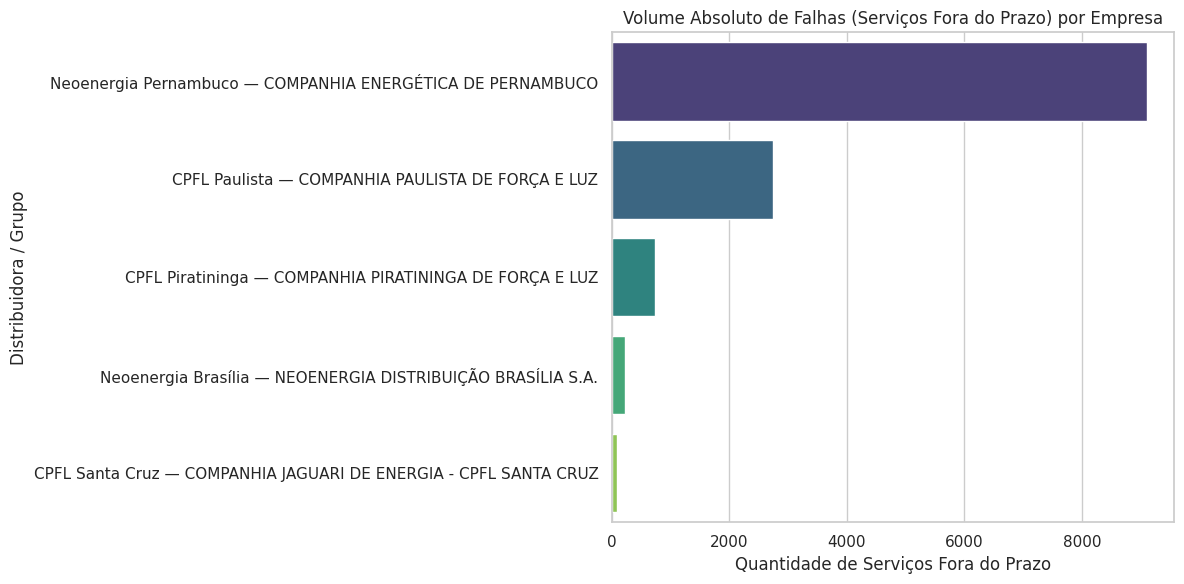

In [6]:
# Gráfico Absoluto: Volume de falhas (qtd_fora_prazo) por grupo
abs_fails = df_top5.groupby('distributor_label')['qtd_fora_prazo'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=abs_fails, x='qtd_fora_prazo', y='distributor_label', palette='viridis')
plt.title('Volume Absoluto de Falhas (Serviços Fora do Prazo) por Empresa')
plt.xlabel('Quantidade de Serviços Fora do Prazo')
plt.ylabel('Distribuidora / Grupo')
plt.tight_layout()
plt.show()

/tmp/ipykernel_113670/1902934777.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agreg_norm, x='taxa_100k_uc', y='distributor_label', palette='magma')


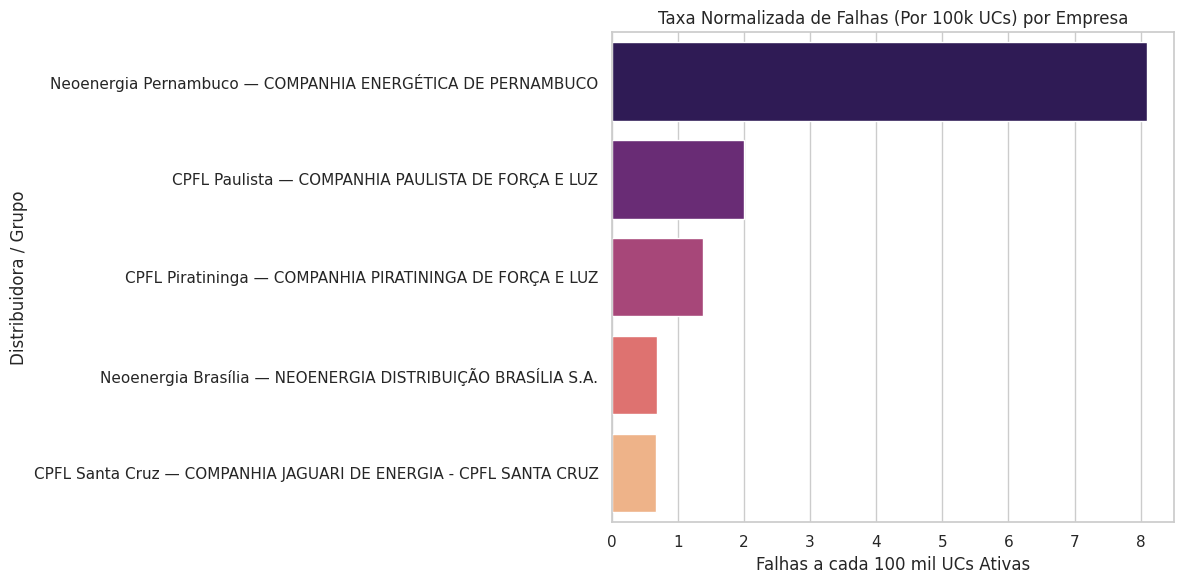

In [7]:
# Gráfico Normalizado: Falhas por 100k Unidades Consumidoras, agrupando pelo grupo
# Agregamos os totais primeiro para calcular uma taxa real consolidada
agreg_norm = df_top5.groupby('distributor_label').agg({
    'qtd_fora_prazo': 'sum',
    'uc_ativa_media_mensal': 'sum' # Assumindo a média do ano soma, ajustado via formula
}).reset_index()

# Calculando a taxa consolidada
agreg_norm['taxa_100k_uc'] = (agreg_norm['qtd_fora_prazo'] / agreg_norm['uc_ativa_media_mensal']) * 100000
agreg_norm = agreg_norm.sort_values(by='taxa_100k_uc', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=agreg_norm, x='taxa_100k_uc', y='distributor_label', palette='magma')
plt.title('Taxa Normalizada de Falhas (Por 100k UCs) por Empresa')
plt.xlabel('Falhas a cada 100 mil UCs Ativas')
plt.ylabel('Distribuidora / Grupo')
plt.tight_layout()
plt.show()

In [1]:
# Heatmap: Proporção de Falhas que ocorrem em áreas Rurais vs Baixa Renda
heatmap_data = pd.pivot_table(
    df_top5,
    values='qtd_fora_prazo',
    index='group_id',
    columns='perfil_social',
    aggfunc='sum',
    fill_value=0
)

# Convertendo para porcentagem por linha (grupo)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% das falhas do grupo'})
plt.title('Mapa de Calor: Onde as falhas acontecem por Grupo (%)')
plt.ylabel('Grupo')
plt.xlabel('Perfil Social do Local')
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined